# 02. Baseline Model — Logistic Regression

**Goal:** Establish a baseline for the LoL early-game win prediction task using a simple 
logistic regression model. The baseline will serve as a reference for evaluating more 
complex models (Random Forest, LightGBM) in subsequent notebooks.

**Preprocessing decisions** (based on EDA findings):
- Drop `gameId` (unique identifier, no predictive value)
- Drop one feature from each redundant pair to avoid multicollinearity
- Standardize all features (required for logistic regression, sensitive to scale)
- Stratified train/test split to preserve class balance

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, classification_report

In [4]:
df = pd.read_csv('../data/raw/high_diamond_ranked_10min.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (9879, 40)


,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,...,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,...,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,...,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,...,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,...,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4


## Feature Selection

Based on EDA findings, we remove redundant features to avoid multicollinearity.

In [5]:
print('blueGoldDiff + redGoldDiff unique values:', (df['blueGoldDiff'] + df['redGoldDiff']).unique())
print('blueExperienceDiff + redExperienceDiff unique values:', (df['blueExperienceDiff'] + df['redExperienceDiff']).unique())

blueGoldDiff + redGoldDiff unique values: [0]
blueExperienceDiff + redExperienceDiff unique values: [0]


## Feature Selection

Based on EDA findings, we remove redundant features to reduce multicollinearity for the 
logistic regression baseline.

**Dropped features and reasoning:**

| Feature | Reason |
|---|---|
| `gameId` | Unique identifier, no predictive value |
| `redKills`, `redDeaths` | Definitional duplicates: blue's kill = red's death |
| `redFirstBlood` | Deterministic complement of `blueFirstBlood` |
| `blueGoldPerMin`, `redGoldPerMin` | Linear transforms of TotalGold (÷10) |
| `blueCSPerMin`, `redCSPerMin` | Linear transforms of TotalMinionsKilled |
| `redGoldDiff`, `redExperienceDiff` | Mirror features with sign flip |
| `blueEliteMonsters`, `redEliteMonsters` | Aggregates of Dragons + Heralds; keeping detail instead |

**Kept features:** 28 (out of original 40).

In [6]:
columns_to_drop = [
    # Identifier
    'gameId',
    
    # Definitional duplicates (blue's kill = red's death)
    'redKills',      # = blueDeaths
    'redDeaths',     # = blueKills
    
    # Deterministic complement
    'redFirstBlood', # = 1 - blueFirstBlood
    
    # Linear transforms (GPM = TotalGold / 10)
    'blueGoldPerMin',
    'redGoldPerMin',
    
    # CS duplicates
    'blueCSPerMin',  # = blueTotalMinionsKilled / 10
    'redCSPerMin',
    
    # Mirror diffs (same info with sign flip)
    'redGoldDiff',        # = -blueGoldDiff
    'redExperienceDiff',  # = -blueExperienceDiff
    
    # Aggregates (keep detail, drop sum)
    'blueEliteMonsters',  # = blueDragons + blueHeralds
    'redEliteMonsters',
]

df_copy = df.copy()
df_copy = df_copy.drop(columns=columns_to_drop)
df_copy.shape

(9879, 28)

In [7]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   blueWins                      9879 non-null   int64  
 1   blueWardsPlaced               9879 non-null   int64  
 2   blueWardsDestroyed            9879 non-null   int64  
 3   blueFirstBlood                9879 non-null   int64  
 4   blueKills                     9879 non-null   int64  
 5   blueDeaths                    9879 non-null   int64  
 6   blueAssists                   9879 non-null   int64  
 7   blueDragons                   9879 non-null   int64  
 8   blueHeralds                   9879 non-null   int64  
 9   blueTowersDestroyed           9879 non-null   int64  
 10  blueTotalGold                 9879 non-null   int64  
 11  blueAvgLevel                  9879 non-null   float64
 12  blueTotalExperience           9879 non-null   int64  
 13  blueTotalMinio

## Train / Test Split

Splitting the dataset into 80% train and 20% test, stratified by target to preserve class balance.

- `test_size=0.2` — 20% held out as a final evaluation set, untouched until the end
- `stratify=y` — ensures class proportions are identical in train and test
- `random_state=42` — fixed seed for reproducibility

In [8]:
X = df_copy.drop(columns=['blueWins'])
y = df_copy['blueWins']

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                   test_size = 0.2,
                                                   stratify=y,
                                                   random_state=42)

print(f'x_train shape: {X_train.shape}')
print(f'x_test shape: {X_test.shape}')
print(f'Class balance in train: {y_train.value_counts(normalize=True).to_dict()}')
print(f'Class balance in test: {y_test.value_counts(normalize=True).to_dict()}')

x_train shape: (7903, 27)
x_test shape: (1976, 27)
Class balance in train: {0: 0.500949006706314, 1: 0.49905099329368596}
Class balance in test: {0: 0.5010121457489879, 1: 0.49898785425101216}


## Feature Scaling

Logistic regression is sensitive to feature scales. Features like `blueTotalGold` (~16,000) 
would dominate the loss function compared to `blueDragons` (0-1), making the model effectively 
ignore small-scale features.

We apply **StandardScaler** to transform each feature to mean=0, std=1.

**Critical practice — avoiding data leakage:**
- `scaler.fit_transform(X_train)` — compute μ and σ **from training data only**
- `scaler.transform(X_test)` — apply the **same** μ and σ to test data

Never `fit_transform` on the combined dataset — this would leak test statistics into training.

In [9]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),
                              columns=X_train.columns,
                              index=X_train.index)

X_test_scaled = pd.DataFrame(scaler.transform(X_test),
                             columns=X_test.columns,
                             index=X_test.index)

print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'Mean of X_train_scaled: {X_train_scaled.values.mean():.6f}')
print(f'Std of X_train_scaled:  {X_train_scaled.values.std():.6f}')
print(f'Mean of X_test_scaled:  {X_test_scaled.values.mean():.6f}')
print(f'Std of X_test_scaled:   {X_test_scaled.values.std():.6f}')

X_train_scaled shape: (7903, 27)
Mean of X_train_scaled: -0.000000
Std of X_train_scaled:  1.000000
Mean of X_test_scaled:  -0.005073
Std of X_test_scaled:   1.002582


## Baseline Model: Logistic Regression

We train a logistic regression as the simplest reasonable baseline for this binary 
classification task. The goal is not to achieve the highest possible score, but to:

1. Verify the preprocessing pipeline works end-to-end
2. Establish a performance floor that more complex models must beat
3. Gain interpretable insights via feature coefficients

**Hyperparameters:**
- `max_iter=1000` — ensures convergence (default 100 sometimes fails on real data)
- `random_state=42` — reproducibility
- Other defaults: L2 regularization, `C=1.0`, `solver='lbfgs'`

In [10]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print(f'Model trained successfully.')
print(f'Number of features: {model.n_features_in_}')
print(f'Number of iterations to converge: {model.n_iter_[0]}')

Model trained successfully.
Number of features: 27
Number of iterations to converge: 23


## Model Evaluation

We evaluate the trained logistic regression on the held-out test set using multiple metrics:

- **Accuracy** — overall proportion of correct predictions. Good for balanced classes.
- **ROC-AUC** — model's ability to rank positives above negatives, threshold-independent.
- **F1 score** — harmonic mean of precision and recall; robust to class imbalance.
- **Confusion matrix** — breakdown of TP, FP, TN, FN for detailed error analysis.

In [11]:
y_pred = model.predict(X_test_scaled)

y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print(f'ROC-AUC:  {roc_auc:.4f}')
print(f'F1 score: {f1:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Blue Loses', 'Blue Wins']))

Accuracy: 0.7161
ROC-AUC:  0.8057
F1 score: 0.7179

Classification Report:
              precision    recall  f1-score   support

  Blue Loses       0.72      0.71      0.71       990
   Blue Wins       0.71      0.72      0.72       986

    accuracy                           0.72      1976
   macro avg       0.72      0.72      0.72      1976
weighted avg       0.72      0.72      0.72      1976



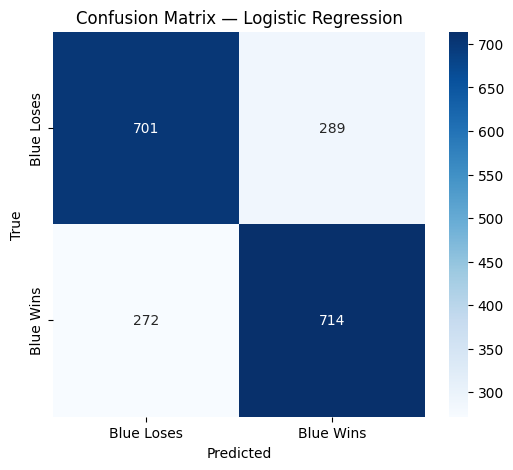

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Blue Loses', 'Blue Wins'],
           yticklabels=['Blue Loses', 'Blue Wins'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Logistic Regression')
plt.show()

In [13]:
coef_df = pd.DataFrame({'feature': X_train.columns,
                       'coefficient': model.coef_[0],})

coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False).reset_index(drop=True)

print('Top 10 most influential features:')
print(coef_df[['feature', 'coefficient']].head(10))

Top 10 most influential features:
                 feature  coefficient
0           blueGoldDiff     0.568159
1          blueTotalGold     0.473471
2           redTotalGold    -0.443633
3     redTotalExperience    -0.246518
4     blueExperienceDiff     0.201894
5            blueDragons     0.161039
6             redDragons    -0.160020
7  redTotalMinionsKilled     0.133028
8             blueDeaths     0.113241
9              blueKills    -0.110400


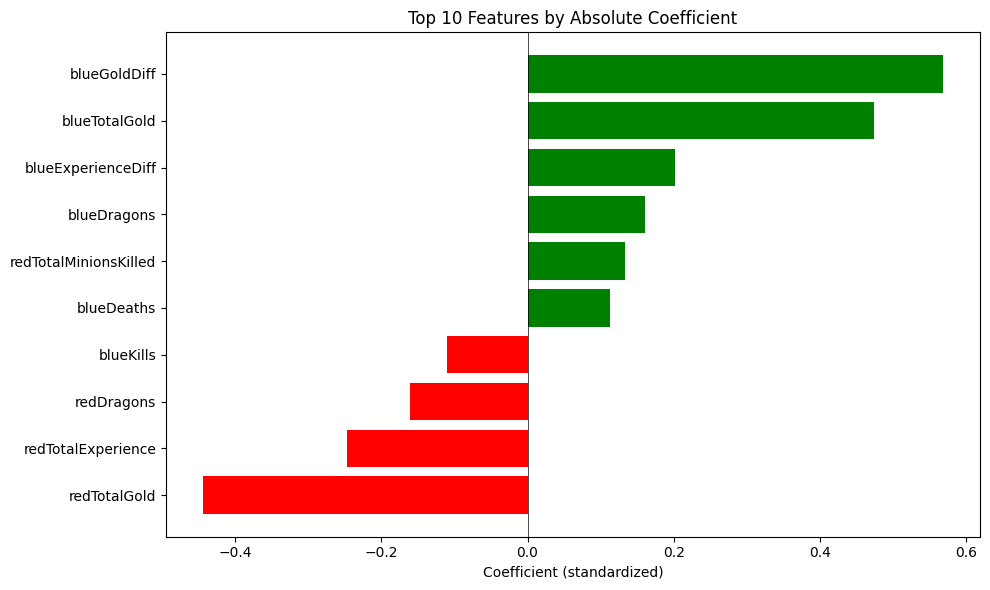

In [14]:
top_10 = coef_df.head(10).sort_values('coefficient')

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in top_10['coefficient']]
plt.barh(top_10['feature'], top_10['coefficient'], color=colors)
plt.xlabel('Coefficient (standardized)')
plt.title('Top 10 Features by Absolute Coefficient')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## Key Insight: Unexpected Coefficient Signs

The logistic regression reveals a counterintuitive pattern:
- `blueDeaths` has a **positive** coefficient (+0.11)
- `blueKills` has a **negative** coefficient (-0.11)

This seems to contradict the intuition that kills help and deaths hurt. However, 
this is a classic **suppressor effect** caused by multicollinearity.

### Explanation

`blueGoldDiff` (coef +0.57) and `blueTotalGold` (coef +0.47) already absorb most of 
the predictive power of kills — kills directly convert to gold (correlation 0.89 
as shown in EDA). Once gold is controlled for, `blueKills` and `blueDeaths` no longer 
represent "team performance". Instead, they encode subtle patterns:

- At fixed `blueGoldDiff`, matches with **more kills on both sides** tend to be more 
  chaotic and not necessarily won by blue.
- At fixed `blueGoldDiff`, matches with **more blue deaths** may indicate active but 
  balanced skirmishes where blue's advantage is structural (farm, objectives) rather 
  than combat-based — a more sustainable advantage.

### Implications

1. **Coefficients of a logistic regression with collinear features do not represent 
   feature importance.** They represent conditional effects after controlling for others.
2. For true feature importance with interactions, we will use SHAP values or permutation 
   importance on non-linear models (Random Forest, LightGBM) in the next notebook.

## Cross-Validation

Single train/test split gives one metric estimate. Cross-validation on the training set 
reveals how stable the model is across different data partitions.

**Setup:**
- 5-fold Stratified CV (preserves class balance in each fold)
- Metrics: ROC-AUC, Accuracy
- Applied on training set only — test set remains untouched for final evaluation

In [15]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# ROC-AUC
cv_roc_auc = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_scaled, y_train,
    cv=cv,
    scoring='roc_auc',
)

# Accuracy
cv_accuracy = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_scaled, y_train,
    cv=cv,
    scoring='roc_auc',)

print(f'CV ROC_AUC: {cv_roc_auc.mean():.4f} ± {cv_roc_auc.std():.4f}')
print(f'  Per-fold:  {[f"{s:.4f}" for s in cv_roc_auc]}')
print()
print(f'CV Accuracy: {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}')
print(f'  Per-fold:  {[f"{s:.4f}" for s in cv_accuracy]}')

CV ROC_AUC: 0.8107 ± 0.0080
  Per-fold:  ['0.8231', '0.8091', '0.8127', '0.7982', '0.8105']

CV Accuracy: 0.8107 ± 0.0080
  Per-fold:  ['0.8231', '0.8091', '0.8127', '0.7982', '0.8105']


### Observations

The cross-validation metrics closely match the held-out test performance 
(ROC-AUC 0.807 on test vs 0.81 mean on CV), and the low standard deviation 
(±0.008) indicates the model is stable across data partitions.

**Implication:** the baseline result is reliable, not an artifact of a lucky split.
The true predictive ceiling of logistic regression on this dataset is around 0.81 ROC-AUC.

## ROC Curve

The ROC curve visualizes the trade-off between True Positive Rate (recall) and 
False Positive Rate at various classification thresholds. The Area Under the Curve 
(AUC) summarizes this trade-off in a single threshold-independent metric.

- AUC = 0.5 → random classifier
- AUC = 1.0 → perfect classifier
- AUC < 0.5 → model is worse than random (usually a bug)

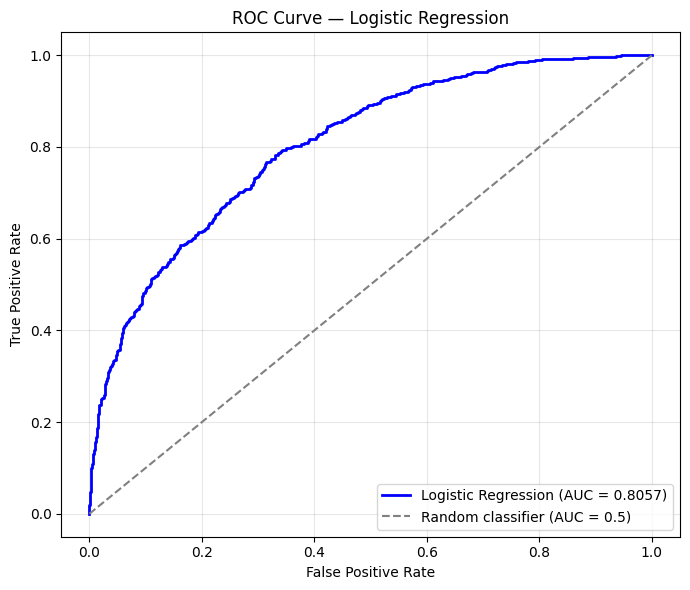

In [16]:
from sklearn.metrics import roc_curve

# Compute ROC points
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random classifier (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()